# 5-minute tour of `poligrain`

This is a very brief overview of features available in the `poligrain` package. A more comprehensive overview of can be found in the `poligrain` [documentation](https://poligrain.readthedocs.io).

In [1]:
import matplotlib.pyplot as plt

import poligrain as plg

## Explore example datasets

We provide the option to download subsets of existing open datasets with opportunistic sensor data. Currently, the following open datasets are supported:
- OpenMRG: CML, rain gauge and radar data in Gothenburg, Sweden (Andersson et al., 2022) https://doi.org/10.5194/essd-14-5411-2022
- OpenRainER: CML and rain gauge data in Emilia-Romagna, Italy (Covi et al., 2026) https://doi.org/10.5194/essd-2026-160
- Amsterdam PWS data: PWS data in Amsterdam, Netherlands (de Vos et al., 2019) https://data.4tu.nl/articles/dataset/Rainfall_observations_datasets_from_Personal_Weather_Stations/12703250
- OpenMesh:  CML, PWS and ASOS reference station data in New York City, USA (Jacoby et al., 2026) https://doi.org/10.5194/essd-2025-238

Below we briefly show how to load a subset of the OpenMRG dataset.

In [2]:
(
    ds_rad,
    ds_cmls,
    ds_gauges_municp,
    ds_gauge_smhi,
) = plg.example_data.load_openmrg(data_dir="example_data", subset="8d")

File already exists at example_data/openmrg_cml_8d.nc
Not downloading!
File already exists at example_data/openmrg_rad_8d.nc
Not downloading!
File already exists at example_data/openmrg_municp_gauge_8d.nc
Not downloading!
File already exists at example_data/openmrg_smhi_gauge_8d.nc
Not downloading!


The CML data is provided in a `xarray.Dataset` following the OpenSense naming conventions defined by ([Fencl et al., 2023](https://pmc.ncbi.nlm.nih.gov/articles/PMC10884596/)).

Note that this example dataset has already been processed and the rain rates `R` per CML are stored. Normally are raw CML dataset would only contain RSL and TSL data.

In [3]:
ds_cmls

<xarray.Dataset> Size: 1GB
Dimensions:       (sublink_id: 2, cml_id: 364, time: 69120)
Coordinates:
  * sublink_id    (sublink_id) <U9 72B 'sublink_1' 'sublink_2'
  * cml_id        (cml_id) int64 3kB 10001 10002 10003 ... 10362 10363 10364
  * time          (time) datetime64[ns] 553kB 2015-07-22 ... 2015-07-29T23:59:50
    site_0_lat    (cml_id) float64 3kB ...
    site_0_lon    (cml_id) float64 3kB ...
    site_1_lat    (cml_id) float64 3kB ...
    site_1_lon    (cml_id) float64 3kB ...
    frequency     (sublink_id, cml_id) float64 6kB ...
    polarization  (sublink_id, cml_id) <U1 3kB ...
    length        (cml_id) float64 3kB ...
Data variables:
    tsl           (time, sublink_id, cml_id) float64 403MB ...
    rsl           (time, sublink_id, cml_id) float64 403MB ...
    R             (sublink_id, cml_id, time) float64 403MB ...
Attributes: (12/14)
    title:                 OpenMRG-CML
    version:               1.1
    source:                Swedish Meteorological and Hydrological Institute ...
    contact:               hydro.fou@smhi.se, jafet.andersson@smhi.se
    license:               https://creativecommons.org/licenses/by-sa/4.0
    doi:                   https://doi.org/10.5281/zenodo.6673750
    ...                    ...
    institution:           NA
    date:                  NA
    history:               NA
    naming convention:     NA
    license restrictions:  NA
    reference:             NA

## Plot point, line and grid data on a map

One key feature of `poligrain` is the ability to plot point, line and grid data on a map. Plotting points and grids is straightforward with `matplotlib`. A fast and flexible way to plot line data was missing before.

Below we show an example of how to plot the rainfall accumulatoin of CMLs, rain gauges and radar on a map.

<Axes: xlabel='lon', ylabel='lat'>

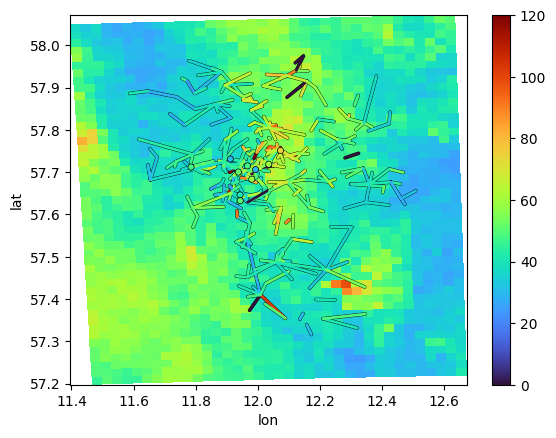

In [4]:
plg.plot_map.plot_plg(
    da_cmls=ds_cmls.isel(sublink_id=0).R.resample(time="1h").mean().sum(dim="time"),
    da_grid=ds_rad.R.resample(time="1h").mean().sum(dim="time"),
    da_gauges=ds_gauges_municp.rainfall_amount.sum(dim="time"),
    vmin=0,
    vmax=120,
)

## Calculate distances between points and lines

In [5]:
# Project coordinates for rain gauges
ds_gauges_municp.coords["x"], ds_gauges_municp.coords["y"] = plg.spatial.project_point_coordinates(
    ds_gauges_municp.lon, ds_gauges_municp.lat, "EPSG:25832"
)

# Project coordinates for CMLs
(
    ds_cmls.coords["site_0_x"],
    ds_cmls.coords["site_0_y"],
) = plg.spatial.project_point_coordinates(
    ds_cmls.site_0_lon, ds_cmls.site_0_lat, "EPSG:25832"
)
(
    ds_cmls.coords["site_1_x"],
    ds_cmls.coords["site_1_y"],
) = plg.spatial.project_point_coordinates(
    ds_cmls.site_1_lon, ds_cmls.site_1_lat, "EPSG:25832"
)

### point-to-point distances

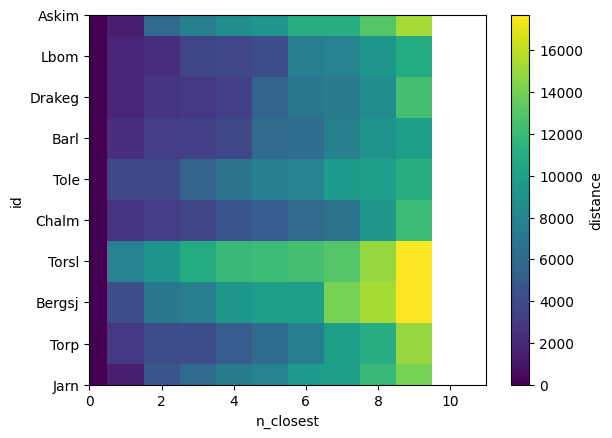

In [7]:
closest_neigbors = plg.spatial.get_closest_points_to_point(
    ds_points=ds_gauges_municp,
    ds_points_neighbors=ds_gauges_municp,
    max_distance=20e3,
    n_closest=12,
)

closest_neigbors.distance.plot();

### point-to-line distances

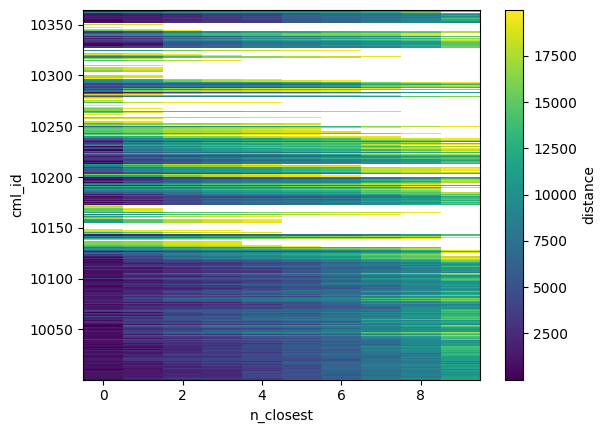

In [10]:
closest_neigbors = plg.spatial.get_closest_points_to_line(
    ds_cmls, ds_gauges_municp, max_distance=20e3, n_closest=10,
)

closest_neigbors.distance.plot()

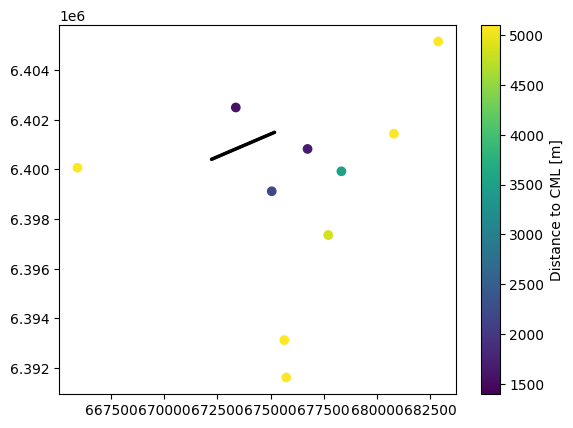

In [11]:
cml_id = 10089
cml_id = 10098
cml_id = 10073

plg.plot_map.plot_plg(
    da_cmls=ds_cmls.sel(cml_id=cml_id),
    use_lon_lat=False,
)

gauge_id = closest_neigbors.sel(cml_id=cml_id).dropna(dim='n_closest').neighbor_id.values
gauge_distance = closest_neigbors.sel(cml_id=cml_id).dropna(dim='n_closest').distance.values

sc = plt.scatter(
    ds_gauges_municp.sel(id=gauge_id).x, 
    ds_gauges_municp.sel(id=gauge_id).y,
    c=gauge_distance, 
    cmap="viridis",
    vmin=1.4e3,
    vmax=5.1e3,
)
plt.colorbar(sc, label="Distance to CML [m]")